In [12]:
#step 1 Environment Setup & Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aesthetics setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries successfully imported.")

Libraries successfully imported.


In [13]:
#step 2 Data Loading, Cleaning & Feature Engineering
# Load dataset
df = pd.read_csv("car data.csv")
print("Initial Dataset Shape:", df.shape)

# Standardize column names
df.columns = df.columns.str.strip()

# Check and remove duplicates / nulls
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows count:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Feature Engineering: Extract brand and calculate vehicle age
df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0].title())
current_year = 2026
df['Car_Age'] = current_year - df['Year']

# Drop raw Car_Name and Year as Car_Age captures temporal decay
df.drop(columns=['Car_Name', 'Year'], inplace=True)

# Standardize categorical strings to lowercase
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("\nEngineered Data Sample:")
df.head()

Initial Dataset Shape: (301, 9)
Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Duplicate rows count: 2

Engineered Data Sample:


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,Ritz,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,Sx4,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,Ciaz,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,Wagon,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,Swift,12


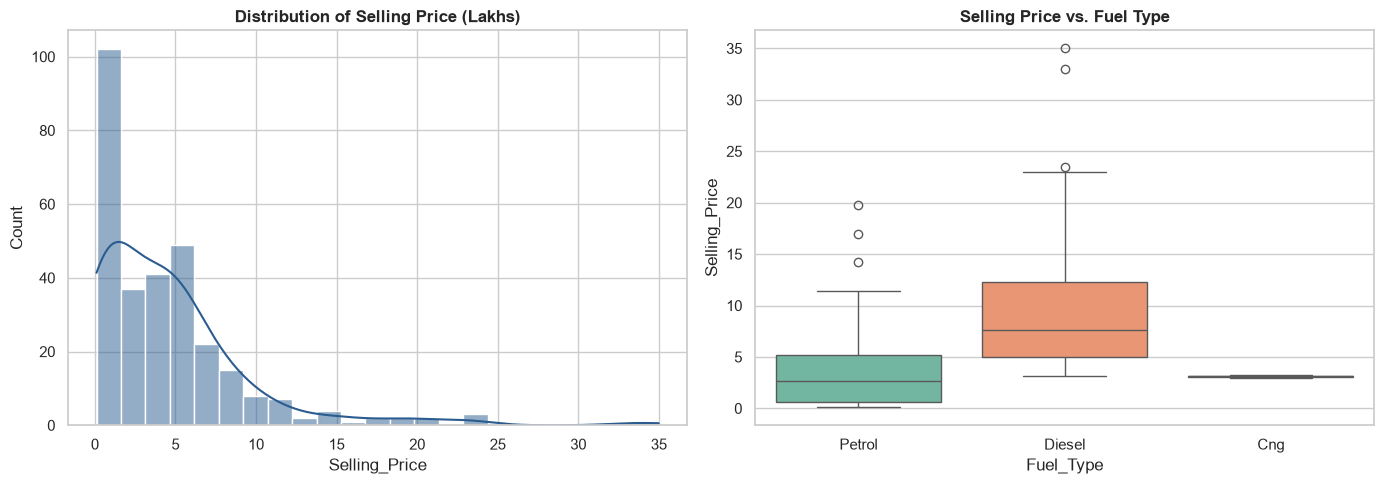

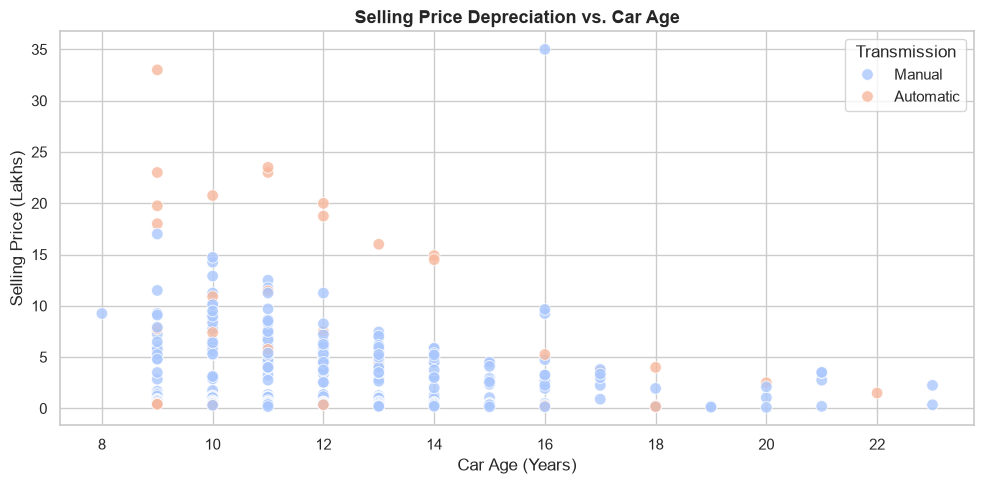

In [14]:
#Step 3: Exploratory Data Analysis (EDA)
# 1. Distribution of Selling Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Selling_Price'], kde=True, color='#2b5c8f', ax=axes[0])
axes[0].set_title("Distribution of Selling Price (Lakhs)", weight='bold')

# 2. Selling Price vs. Fuel Type Boxplot
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', palette='Set2', ax=axes[1], hue='Fuel_Type', legend=False)
axes[1].set_title("Selling Price vs. Fuel Type", weight='bold')
plt.tight_layout()
plt.show()

# 3. Selling Price vs. Car Age Scatter Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', hue='Transmission', palette='coolwarm', s=70, alpha=0.8)
plt.title("Selling Price Depreciation vs. Car Age", fontsize=13, weight='bold')
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

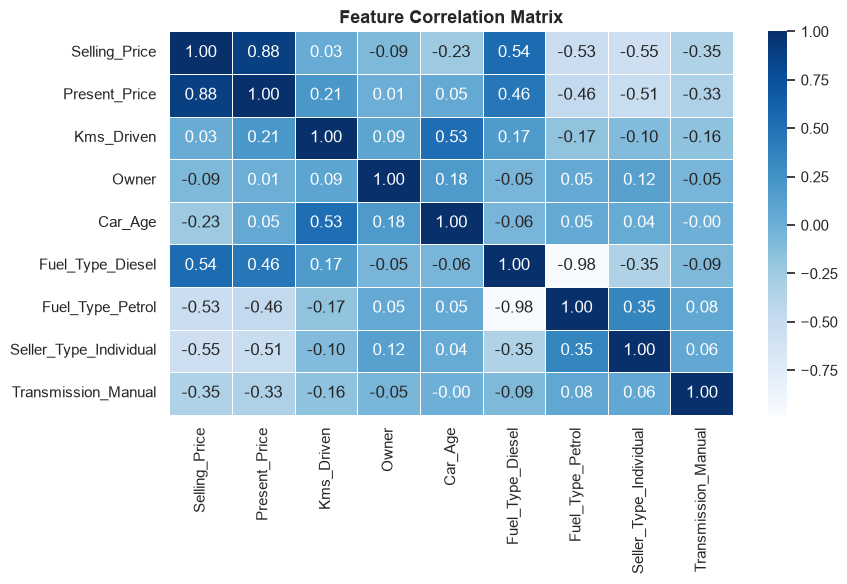

In [15]:
#Step 4: Categorical Encoding & Correlation Heatmap
# Apply One-Hot Encoding to categorical columns
# (Dropping first level to prevent dummy variable trap)
df_encoded = pd.get_dummies(df.drop(columns=['Brand']), drop_first=True)

# Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

In [16]:
#Step 5: Model Training & Comparison
# Feature matrix and target vector
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and collect performance metrics
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R² Score": round(r2, 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.473,2.524,0.7528
1,Random Forest,1.408,3.322,0.5717
2,Gradient Boosting,1.165,2.622,0.7333


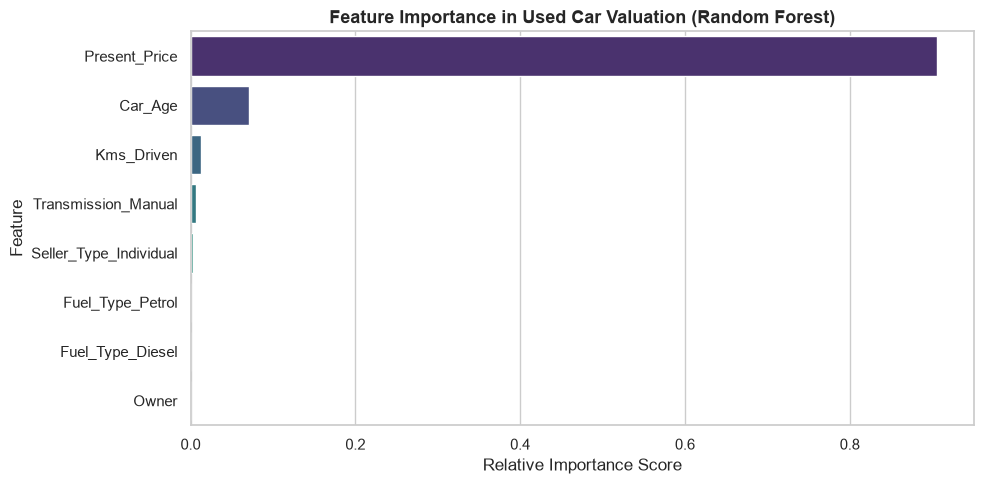

In [17]:
#Step 6: Feature Importance Analysis & Conclusion
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis', hue=importances.index, legend=False)
plt.title("Feature Importance in Used Car Valuation (Random Forest)", fontsize=13, weight='bold')
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()